<a href="https://colab.research.google.com/github/nkefeyan-22-26/ECON5200-Applied-Data-Analytics-in-Economics/blob/main/Assignment3/Econ_5200_Assignment_3_Causal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Assignment 3: The Causal Architecture**
Nathan Kefeyan

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

In [3]:
# Data Generating Process
np.random.seed(42)
zeros = np.zeros(100)
tips = np.random.exponential(scale=5.0, size=150)
driver_tips = np.concatenate([zeros, tips])

In [4]:
resample_n = 10000
n = len(driver_tips)
boot_medians = np.empty(10000)


for i in range(10000):
    resample = np.random.choice(driver_tips, size=n, replace=True)
    boot_medians[i] = np.median(resample)

ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])
median = np.median(driver_tips)

print(f"Observed median: {median:.2f}")
print(f"95% bootstrap CI (percentile): {ci_low:.4f}, {ci_high:.4f}")

Observed median: 0.76
95% bootstrap CI (percentile): 0.2653, 1.3636


The observed median is $0.76, which is how much the typical driver earns in tips. The 95% CI of [0.26, 1.3] has a lower margin of $0.50, wheras the upper margin is $0.54. This shows that it is asymmetric, which means that there is an underlying skew in the data.

In [5]:
np.random.seed(42)

control = np.random.normal(loc=35.0, scale=5.0, size=500)
treat = np.random.lognormal(mean=3.4, sigma=0.4, size=500)

# control mean - treatment mean
observed_diff = control.mean() - treat.mean()

print(f"Control mean: {control.mean():.4f}")
print(f"Treatment mean: {treat.mean():.4f}")
print(f"Observed Difference: {observed_diff:.4f}")

Control mean: 35.0342
Treatment mean: 32.7692
Observed Difference: 2.2650


The batch routhing algorithm saves about 2.27 minutes on average.

In [6]:
n_permutations = 5000
perm_diffs = np.empty(n_permutations)

combined = np.concatenate([control, treat])

for i in range(n_permutations):
    shuffled = np.random.permutation(combined)
    perm_diffs[i] = shuffled[:500].mean() - shuffled[500:].mean()

p_val = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()

print(f"Observed difference : {observed_diff:.4f} min")
print(f"Empirical p-value   : {p_val:.4f}")

Observed difference : 2.2650 min
Empirical p-value   : 0.0004


The permutation test returns a significant p-value of 0.0004, meaning only .04% of the random shuffles produced the observed difference of this size due purely to random chance.

In [8]:
FILEPATH = "/content/swiftcart_loyalty.csv"
df = pd.read_csv(FILEPATH)
df.head()

,subscriber,pre_spend,account_age,support_tickets,post_spend
0,1,57.450712,37,2,85.169648
1,1,47.926035,41,0,72.802404
2,1,59.715328,41,0,79.858905
3,1,72.845448,34,0,80.335466
4,1,46.487699,34,2,67.956227


In [13]:
subscribers = df[df["subscriber"]==1]["post_spend"]
non_subscribers = df[df["subscriber"]==0]["post_spend"]
sdo = subscribers.mean() - non_subscribers.mean()

mean_subs = subscribers.mean()
mean_nonsubs = non_subscribers.mean()

print(f"Subscribers mean: ${mean_subs:.2f}")
print(f"Non-Subscribers mean: ${mean_subs:.2f}")
print(f"Naive SDO: ${sdo:.2f}")
print(f"Implied lift: {sdo / mean_nonsubs * 100:.1f}%")

Subscribers mean: $74.04
Non-Subscribers mean: $74.04
Naive SDO: $17.57
Implied lift: 31.1%


The naive SDO reports a $17.57 or about 31.1% lift, which justifies doubling the budget.

In [16]:
covariates = ['pre_spend', 'account_age', 'support_tickets']

X = df [covariates]
y = df ["subscriber"]

logit = LogisticRegression ()
logit.fit(X, y)

df['propensity_score'] = logit.predict_proba(X) [:,1]

treat = df[df['subscriber'] == 1]
control = df[df['subscriber'] == 0]

nbrs = NearestNeighbors(n_neighbors=1)
nbrs.fit(df[df['subscriber'] == 0][['propensity_score']])

distances, indices = nbrs.kneighbors(treat[['propensity_score']])

matched_control = control.iloc[indices.flatten()]['post_spend'].values

# ATT = differences between mean of treated and mean of matched control
att = treat['post_spend'].values.mean() - matched_control.mean()

print(f"\nMatched control mean: ${matched_control.mean():.2f}")
print(f"ATT: ${att:.2f}")
print(f"Implied lift: {att / matched_control.mean() * 100:.1f}%")


Matched control mean: $64.13
ATT: $9.91
Implied lift: 15.5%


PSM cuts the previous number by a significant amount due to selection bias.

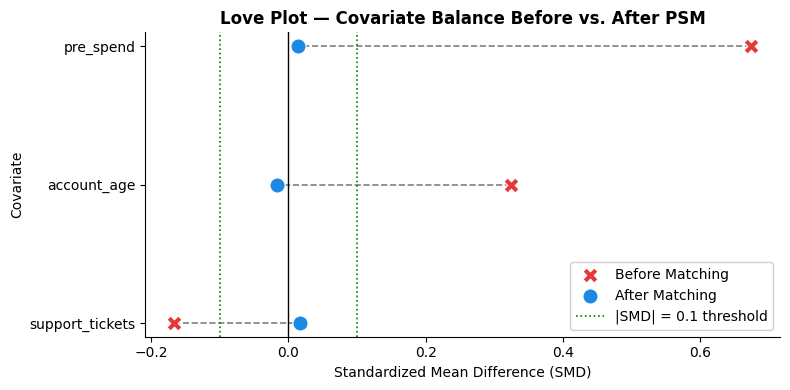

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Helper: Standardized Mean Difference ──────────────────────────────────
def smd(df, covariates):
    treated   = df[df['subscriber'] == 1]
    control   = df[df['subscriber'] == 0]
    diffs = {}
    for col in covariates:
        diff = (treated[col].mean() - control[col].mean()) / (
               np.sqrt((treated[col].var() + control[col].var()) / 2))
        diffs[col] = diff
    return diffs

# ── Construct df_matched from PSM results (Step 3.2) ─────────────────────
treated_df       = df[df['subscriber'] == 1].copy()
matched_ctrl_idx = df[df['subscriber'] == 0].iloc[indices.flatten()].index
matched_ctrl_df  = df.loc[matched_ctrl_idx].copy()
df_matched       = pd.concat([treated_df, matched_ctrl_df])
df_unmatched     = df.copy()

# ── Compute SMDs ──────────────────────────────────────────────────────────
covariates = ['pre_spend', 'account_age', 'support_tickets']

smd_before = smd(df_unmatched, covariates)
smd_after  = smd(df_matched,   covariates)

plot_df = pd.DataFrame({
    'Covariate' : covariates,
    'Before'    : [smd_before[c] for c in covariates],
    'After'     : [smd_after[c]  for c in covariates],
})

# ── Love Plot ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))

sns.scatterplot(data=plot_df, x='Before', y='Covariate',
                color='#E53935', marker='X', s=120, label='Before Matching', ax=ax, zorder=3)
sns.scatterplot(data=plot_df, x='After',  y='Covariate',
                color='#1E88E5', marker='o', s=120, label='After Matching',  ax=ax, zorder=3)

# Connect before/after per covariate
for _, row in plot_df.iterrows():
    ax.plot([row['Before'], row['After']], [row['Covariate'], row['Covariate']],
            color='grey', lw=1.2, ls='--', zorder=2)

# Threshold lines
ax.axvline(0,    color='black', lw=1.0, ls='-')
ax.axvline( 0.1, color='green', lw=1.2, ls=':', label='|SMD| = 0.1 threshold')
ax.axvline(-0.1, color='green', lw=1.2, ls=':')

ax.set_xlabel('Standardized Mean Difference (SMD)')
ax.set_title('Love Plot — Covariate Balance Before vs. After PSM', fontweight='bold')
ax.legend(framealpha=0.9)
sns.despine()
plt.tight_layout()
plt.show()